In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


In [2]:
sistema = [
    dict(m = 1, r = [0, 0, 0], v = [0, 0, 0]),
    dict(m = 1, r = [1, 0, 0], v = [0, 1, 0])
]

In [3]:
ts = np.linspace(0, 10, 100)
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

In [4]:
rs.shape

(2, 100, 3)

La rutina anterior devuelve un cubo de datos, donde el primer índice es el número de partículas, el segundo representa el tiempo y el tercero la coordenada.

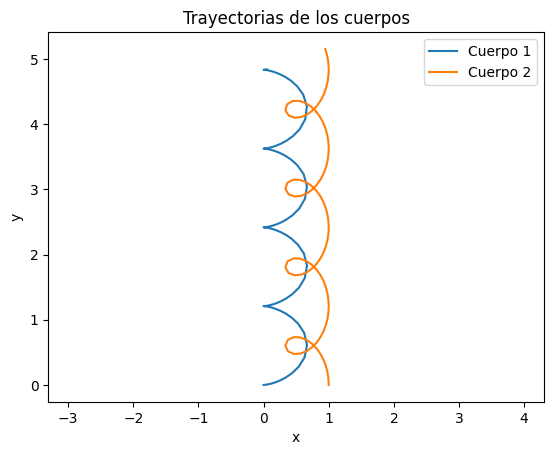

In [5]:
plt.plot(rs[0, :, 0], rs[0, :, 1], label='Cuerpo 1')
plt.plot(rs[1, :, 0], rs[1, :, 1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

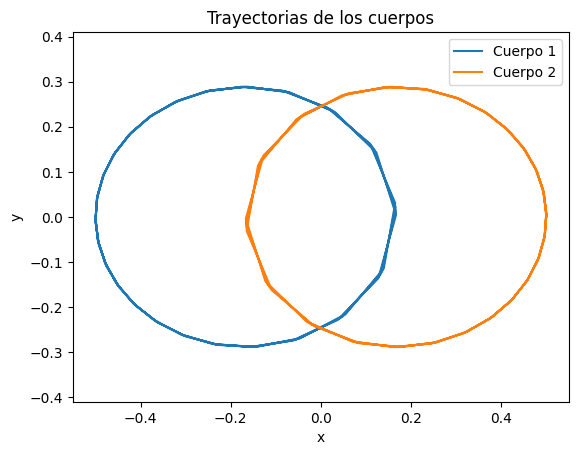

In [6]:
plt.plot(rps[0, :, 0], rps[0, :, 1], label='Cuerpo 1')
plt.plot(rps[1, :, 0], rps[1, :, 1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

# CUADRATURAS

In [7]:
# Momento lineal

suma = 0
for i in range(2):
    suma += sistema[i]['m'] * vs[i, 42, :]

suma

array([0., 1., 0.])

In [8]:
# Momentum angular

suma = 0

for i in range(2):
    suma += sistema[i]['m'] * np.cross(rs[i, 42, :], vs[i, 42, :])

suma

array([0.       , 0.       , 0.9999998])

In [9]:
sistema[0]['m'] * vs[0] + sistema[1]['m'] * vs[1]

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1

In [10]:
# Expandimos la dimensión de las masas a (n_particulas, 1, 1) para hacer broadcasting
masas = np.array([c['m'] for c in sistema])[:, None, None]

# Calculamos la suma en todos los instantes (axis=0 suma sobre las partículas)
suma_todos_tiempos = np.sum(masas * np.cross(rs, vs), axis=0)

suma_todos_tiempos

array([[0.        , 0.        , 1.        ],
       [0.        , 0.        , 0.99999999],
       [0.        , 0.        , 0.99999998],
       [0.        , 0.        , 0.99999997],
       [0.        , 0.        , 0.99999997],
       [0.        , 0.        , 0.99999995],
       [0.        , 0.        , 0.99999991],
       [0.        , 0.        , 0.99999987],
       [0.        , 0.        , 0.99999983],
       [0.        , 0.        , 0.99999981],
       [0.        , 0.        , 0.99999983],
       [0.        , 0.        , 0.99999991],
       [0.        , 0.        , 0.99999984],
       [0.        , 0.        , 0.99999987],
       [0.        , 0.        , 0.99999985],
       [0.        , 0.        , 0.99999984],
       [0.        , 0.        , 0.99999984],
       [0.        , 0.        , 0.99999984],
       [0.        , 0.        , 0.99999984],
       [0.        , 0.        , 0.99999984],
       [0.        , 0.        , 0.99999984],
       [0.        , 0.        , 0.99999983],
       [0.